# Ejercicio 2 — Alimentos y pacientes

---

> El dataset `alimentos.csv` fue elaborado por una clínica de nutrición que suministró a sus pacientes una lista de alimentos permitidos con sus respectivos contenidos calóricos. También se detalló el tipo de alimento del que se trataba (fruta, verdura, etc.) y el tipo de vitamina que aportaba cada uno (A, B o C).
>
> Por otra parte, la nutricionista a cargo del estudio lleva una planilla de control de la evolución de 50 pacientes (`pacientes.csv`) en la que registra la edad, el sexo, la altura, el peso inicial y el peso final de cada uno de ellos luego de seguir un plan de dieta por una cierta cantidad de tiempo, información que también fue registrada en el campo "tiempo de tratamiento".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

---
## Ítem 1

> **Importe ambos datasets al entorno de trabajo y realice cualquier tarea de limpieza y/o adecuación de los mismos que considere necesaria.**

In [2]:
# El archivo usa separador ';' y codificación latin-1 (caracteres especiales en español)
alimentos = pd.read_csv('../Datasets/alimentos.csv', sep=';', encoding='latin-1')

# Limpiar espacios extra en columnas de texto
for col in alimentos.select_dtypes('object').columns:
    alimentos[col] = alimentos[col].str.strip()

print(f'Shape: {alimentos.shape}')
print(f'Valores faltantes:\n{alimentos.isnull().sum()}')
print(f'Duplicados: {alimentos.duplicated().sum()}')
print(f"\nTipos de alimento: {sorted(alimentos['tipo_de_alimento'].unique())}")
alimentos.head()

Shape: (99, 4)
Valores faltantes:
alimento                0
aporte_calorico_kcal    0
tipo_de_alimento        0
vitamina                0
dtype: int64
Duplicados: 0

Tipos de alimento: ['animal', 'elaborada', 'fruta', 'fruto seco', 'verdura']


C:\Users\PC\AppData\Local\Temp\ipykernel_15124\1393559291.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in alimentos.select_dtypes('object').columns:


,alimento,aporte_calorico_kcal,tipo_de_alimento,vitamina
0,banana,81,fruta,A
1,kiwi,36,fruta,B
2,higo,62,fruta,B
3,repollo,22,verdura,A
4,col,12,verdura,A


In [3]:
# altura_m usa coma como separador decimal (ej: 1,8 → 1.8)
pacientes = pd.read_csv('../Datasets/pacientes.csv', sep=';', decimal=',')
pacientes.columns = pacientes.columns.str.strip()

print(f'Shape: {pacientes.shape}')
print(f'Valores faltantes:\n{pacientes.isnull().sum()}')
print(f'Duplicados: {pacientes.duplicated().sum()}')
print(f'\nTipos de datos:\n{pacientes.dtypes}')
pacientes.head()

Shape: (50, 6)
Valores faltantes:
codigo_paciente            0
peso_inicial_kg            0
peso_final_kg              0
altura_m                   0
sexo                       0
tiempo_tratamiento_dias    0
dtype: int64
Duplicados: 0

Tipos de datos:
codigo_paciente              int64
peso_inicial_kg              int64
peso_final_kg                int64
altura_m                   float64
sexo                           str
tiempo_tratamiento_dias      int64
dtype: object


,codigo_paciente,peso_inicial_kg,peso_final_kg,altura_m,sexo,tiempo_tratamiento_dias
0,398911,78,72,1.80,F,583
1,398912,68,68,1.75,F,159
2,398913,92,70,1.85,F,70
3,398914,66,64,1.65,M,41
4,398915,51,50,1.55,F,30


---
## Ítem 2

> **En relación al campo `aporte_calorico_kcal` informe las medidas descriptivas que le brinden información sobre los siguientes aspectos:**
> - Las kcal que aportan, en promedio, los alimentos que forman parte del dataset.
> - Aquel valor de aporte calórico tal que el 50% de los alimentos del dataset presentan aportes calóricos menores o iguales a él.
> - La dispersión o variabilidad del 50% central de las observaciones.
> - El o los valores que se presentan con mayor frecuencia entre las observaciones.

In [4]:
cal = alimentos['aporte_calorico_kcal']

q1 = cal.quantile(0.25)
q3 = cal.quantile(0.75)
iqr = q3 - q1

print('--- Kcal promedio (Media) ---')
print(f'  Media: {cal.mean():.2f} kcal')

print('\n--- Valor que el 50% no supera (Mediana) ---')
print(f'  Mediana: {cal.median():.2f} kcal')

print('\n--- Dispersión del 50% central (Rango Intercuartil) ---')
print(f'  Q1 = {q1:.2f} kcal | Q3 = {q3:.2f} kcal | RIC = {iqr:.2f} kcal')

print('\n--- Valor(es) más frecuente(s) (Moda) ---')
print(f'  {cal.mode().values}')

--- Kcal promedio (Media) ---
  Media: 124.51 kcal

--- Valor que el 50% no supera (Mediana) ---
  Mediana: 66.00 kcal

--- Dispersión del 50% central (Rango Intercuartil) ---
  Q1 = 31.50 kcal | Q3 = 93.50 kcal | RIC = 62.00 kcal

--- Valor(es) más frecuente(s) (Moda) ---
  [20 75]


---
## Ítem 3

> **Represente la distribución de las observaciones de la variable `aporte_calorico_kcal` a través de un boxplot.**
> - Identifique en el gráfico la mediana, el primer y el tercer cuartil.
> - ¿Cómo caracterizaría a la distribución en relación a sus características de simetría?
> - En función a lo observado, ¿qué par de medidas de centralidad/posición (media aritmética - mediana) y de dispersión (rango intercuartil - rango - desviación estándar) le parece más adecuada para describir a este conjunto?
> - ¿Existe alguna observación que pueda ser considerada como atípica? En caso de respuesta afirmativa, ¿cuántas observaciones recibirían esta calificación?

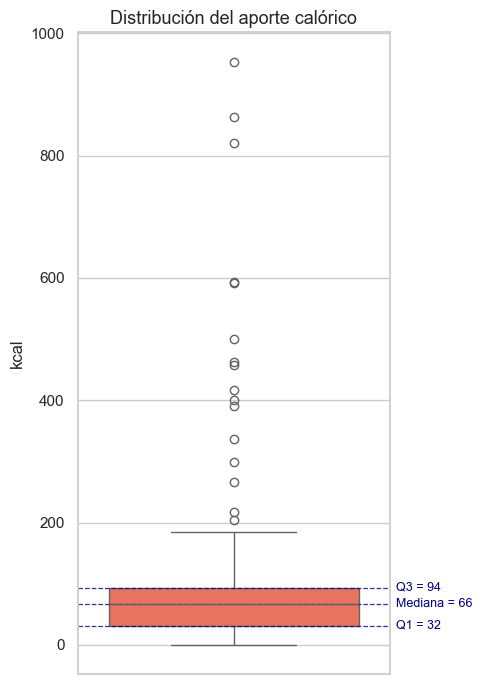

In [5]:
mediana = cal.median()

fig, ax = plt.subplots(figsize=(5, 7))
sns.boxplot(y=cal, ax=ax, color='tomato')

for val, label in [(q1, f'Q1 = {q1:.0f}'), (mediana, f'Mediana = {mediana:.0f}'), (q3, f'Q3 = {q3:.0f}')]:
    ax.axhline(val, color='navy', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.text(0.52, val, label, va='center', fontsize=9, color='navy')

ax.set_title('Distribución del aporte calórico', fontsize=13)
ax.set_ylabel('kcal')
plt.tight_layout()
plt.show()

In [6]:
limite_sup = q3 + 1.5 * iqr
limite_inf = q1 - 1.5 * iqr
outliers = alimentos[(cal > limite_sup) | (cal < limite_inf)]

print(f'Límite inferior: {limite_inf:.2f} kcal | Límite superior: {limite_sup:.2f} kcal')
print(f'Cantidad de valores atípicos: {len(outliers)}')
print(outliers[['alimento', 'aporte_calorico_kcal', 'tipo_de_alimento']])

Límite inferior: -61.50 kcal | Límite superior: 186.50 kcal
Cantidad de valores atípicos: 16
                 alimento  aporte_calorico_kcal tipo_de_alimento
6             hamburguesa                   954        elaborada
13                  pizza                   591        elaborada
22                 salame                   390        elaborada
42    chocolate con leche                   864        elaborada
46              empanadas                   400        elaborada
47              mermelada                   267        elaborada
48         pan de plátano                   820        elaborada
53                   nuez                   593       fruto seco
54             nuez pecan                   299       fruto seco
55               avellana                   204       fruto seco
56               almendra                   458       fruto seco
66                   coco                   416       fruto seco
71              arrollado                   463        elabora

### Interpretación

- **Simetría**: la mediana está más cerca de Q1 que de Q3, y la caja tiene una cola superior más larga → distribución con **sesgo positivo** (asimétrica a la derecha).
- **Medidas recomendadas**: dado el sesgo y la presencia de outliers, se prefiere la **mediana** como centralidad y el **rango intercuartil (RIC)** como dispersión, ya que ambas son robustas frente a valores extremos.

---
## Ítem 4

> **¿Qué tipo de alimento presenta la mayor mediana de aporte calórico?**

In [7]:
medianas_por_tipo = alimentos.groupby('tipo_de_alimento')['aporte_calorico_kcal'].median().sort_values(ascending=False)
print('Mediana de aporte calórico por tipo de alimento:')
print(medianas_por_tipo.round(2))
print(f"\nTipo con mayor mediana: '{medianas_por_tipo.idxmax()}' ({medianas_por_tipo.max():.2f} kcal)")

Mediana de aporte calórico por tipo de alimento:
tipo_de_alimento
elaborada     217.0
fruto seco    113.0
fruta          55.0
animal         49.5
verdura        37.0
Name: aporte_calorico_kcal, dtype: float64

Tipo con mayor mediana: 'elaborada' (217.00 kcal)


---
## Ítem 5

> **Realice un boxplot para representar la distribución de los aportes calóricos de alimentos de los siguientes tipos: frutas, verduras y alimentos elaborados.**
> - ¿Qué tipo de alimentos presenta valores calóricos más variables y cuál menos variables?
> - ¿Qué medida descriptiva utilizó para responder a estas últimas preguntas?

*Nota: en el dataset el tipo "alimentos elaborados" figura como `'elaborada'`.*

C:\Users\PC\AppData\Local\Temp\ipykernel_15124\1035153016.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


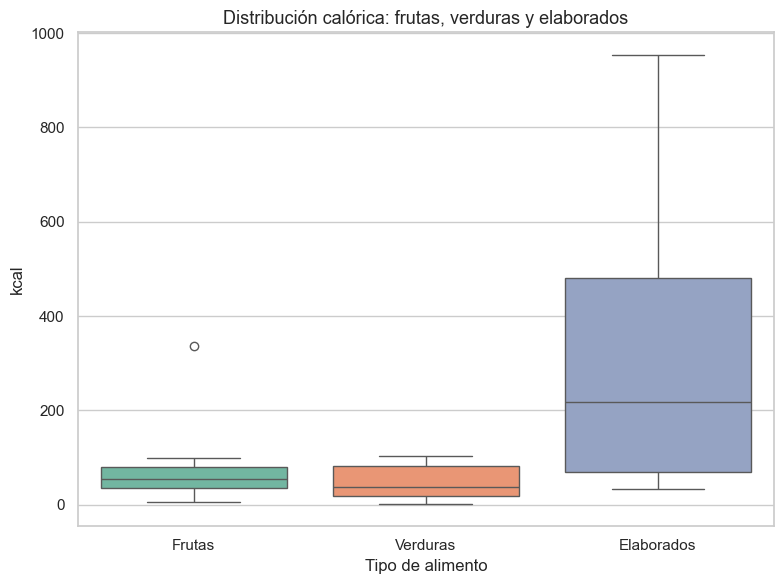

In [8]:
tipos_interes = ['fruta', 'verdura', 'elaborada']
labels = {'fruta': 'Frutas', 'verdura': 'Verduras', 'elaborada': 'Elaborados'}

subset = alimentos[alimentos['tipo_de_alimento'].isin(tipos_interes)].copy()
subset['tipo_label'] = subset['tipo_de_alimento'].map(labels)

orden = ['Frutas', 'Verduras', 'Elaborados']

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=subset,
    x='tipo_label',
    y='aporte_calorico_kcal',
    order=orden,
    palette='Set2',
    ax=ax
)
ax.set_title('Distribución calórica: frutas, verduras y elaborados', fontsize=13)
ax.set_xlabel('Tipo de alimento')
ax.set_ylabel('kcal')
plt.tight_layout()
plt.show()

In [9]:
ric_por_tipo = (
    subset.groupby('tipo_de_alimento')['aporte_calorico_kcal']
    .apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .rename('RIC (kcal)')
    .rename(index=labels)
    .sort_values(ascending=False)
)
print('Rango intercuartil (RIC) por tipo de alimento:')
print(ric_por_tipo.round(2))
print(f"\nMás variable:   {ric_por_tipo.idxmax()} (RIC = {ric_por_tipo.max():.2f} kcal)")
print(f"Menos variable: {ric_por_tipo.idxmin()} (RIC = {ric_por_tipo.min():.2f} kcal)")
print('\nMedida utilizada: Rango Intercuartil (RIC).')

Rango intercuartil (RIC) por tipo de alimento:
tipo_de_alimento
Elaborados    412.0
Verduras       65.0
Frutas         44.0
Name: RIC (kcal), dtype: float64

Más variable:   Elaborados (RIC = 412.00 kcal)
Menos variable: Frutas (RIC = 44.00 kcal)

Medida utilizada: Rango Intercuartil (RIC).


---
## Ítem 6

> **Utilizando los datos de los/las pacientes, genere una variable que corresponda a la variación de peso para cada paciente a lo largo del tratamiento (`peso_final_kg` - `peso_inicial_kg`).**
> - Represente los valores observados de la variable "diferencia de peso" en función del sexo a través de un boxplot.
> - ¿Qué medida descriptiva utilizaría para comparar los resultados del tratamiento entre personas de ambos sexos? En función de su respuesta, ¿las personas de qué sexo obtuvieron los mejores resultados para el tratamiento?

C:\Users\PC\AppData\Local\Temp\ipykernel_15124\921829790.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


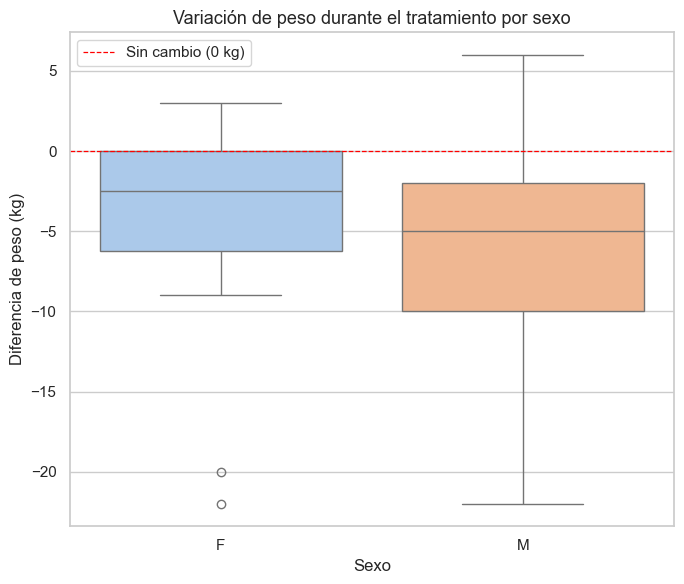

In [10]:
pacientes['diferencia_peso'] = pacientes['peso_final_kg'] - pacientes['peso_inicial_kg']

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(
    data=pacientes,
    x='sexo',
    y='diferencia_peso',
    palette='pastel',
    ax=ax
)
ax.axhline(0, color='red', linestyle='--', linewidth=0.9, label='Sin cambio (0 kg)')
ax.set_title('Variación de peso durante el tratamiento por sexo', fontsize=13)
ax.set_xlabel('Sexo')
ax.set_ylabel('Diferencia de peso (kg)')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
mediana_por_sexo = pacientes.groupby('sexo')['diferencia_peso'].median().round(2)
print('Mediana de variación de peso por sexo:')
print(mediana_por_sexo)
print()
print('Se utiliza la MEDIANA porque la distribución puede presentar sesgo u outliers.')
mejor_sexo = mediana_por_sexo.idxmin()   # valor más negativo = mayor pérdida de peso
print(f'\nLas personas de sexo "{mejor_sexo}" obtuvieron mejores resultados'
      f' (mediana de variación: {mediana_por_sexo[mejor_sexo]:.2f} kg).')

Mediana de variación de peso por sexo:
sexo
F   -2.5
M   -5.0
Name: diferencia_peso, dtype: float64

Se utiliza la MEDIANA porque la distribución puede presentar sesgo u outliers.

Las personas de sexo "M" obtuvieron mejores resultados (mediana de variación: -5.00 kg).
